In [7]:
%load_ext autoreload
%autoreload 2

In [8]:
import pandas as pd
import functions
from google.cloud import bigquery

In [9]:
import yaml

with open("../config.yaml", "r") as f:
    config = yaml.safe_load(f)

In [10]:
client = bigquery.Client()

In [15]:
# functions.data_loader()

In [16]:
# functions.export_clean_data()

In [11]:
general = f"""
SELECT *
FROM `{config['tables']['mart_apps_summary']}`
LIMIT 1000
"""
df = client.query(general).to_dataframe()

In [12]:
df.head(20)

,app,category,app_type,rating,installs,price,review_count,avg_sentiment,positive_review_pct,is_paid
0,"""i DT"" Fútbol. Todos Somos Técnicos.",SPORTS,Free,NaN,500,0.00,<NA>,NaN,NaN,False
1,+Download 4 Instagram Twitter,SOCIAL,Free,4.5,1000000,0.00,<NA>,NaN,NaN,False
2,- Free Comics - Comic Apps,COMICS,Free,3.5,10000,0.00,<NA>,NaN,NaN,False
3,.R,TOOLS,Free,4.5,10000,0.00,<NA>,NaN,NaN,False
4,/u/app,COMMUNICATION,Free,4.7,10000,0.00,<NA>,NaN,NaN,False
5,058.ba,NEWS_AND_MAGAZINES,Free,4.4,100,0.00,<NA>,NaN,NaN,False
6,1. FC Köln App,SPORTS,Free,4.6,100000,0.00,<NA>,NaN,NaN,False
7,10 Best Foods for You,HEALTH_AND_FITNESS,Free,4.0,500000,0.00,194,0.470733,0.835052,False
8,10 Minutes a Day Times Tables,FAMILY,Free,4.1,100000,0.00,<NA>,NaN,NaN,False
9,10 WPM Amateur ham radio CW Morse code trainer,COMMUNICATION,Paid,3.5,100,1.49,<NA>,NaN,NaN,True


In [13]:
# Top categories , Paid vs free , Rating vs sentiment , Sentiment distribution

<Axes: xlabel='category'>

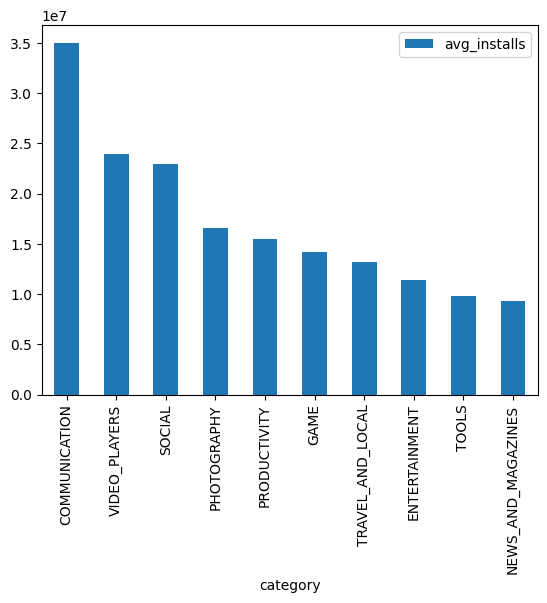

In [14]:
category_installs=f"""
SELECT
    category,
    AVG(installs) AS avg_installs
FROM `{config['tables']['mart_apps_summary']}`
GROUP BY category
ORDER BY avg_installs DESC
LIMIT 10
"""

df1 = client.query(category_installs).to_dataframe()

df1.plot(
    x="category",
    y="avg_installs",
    kind="bar"
)